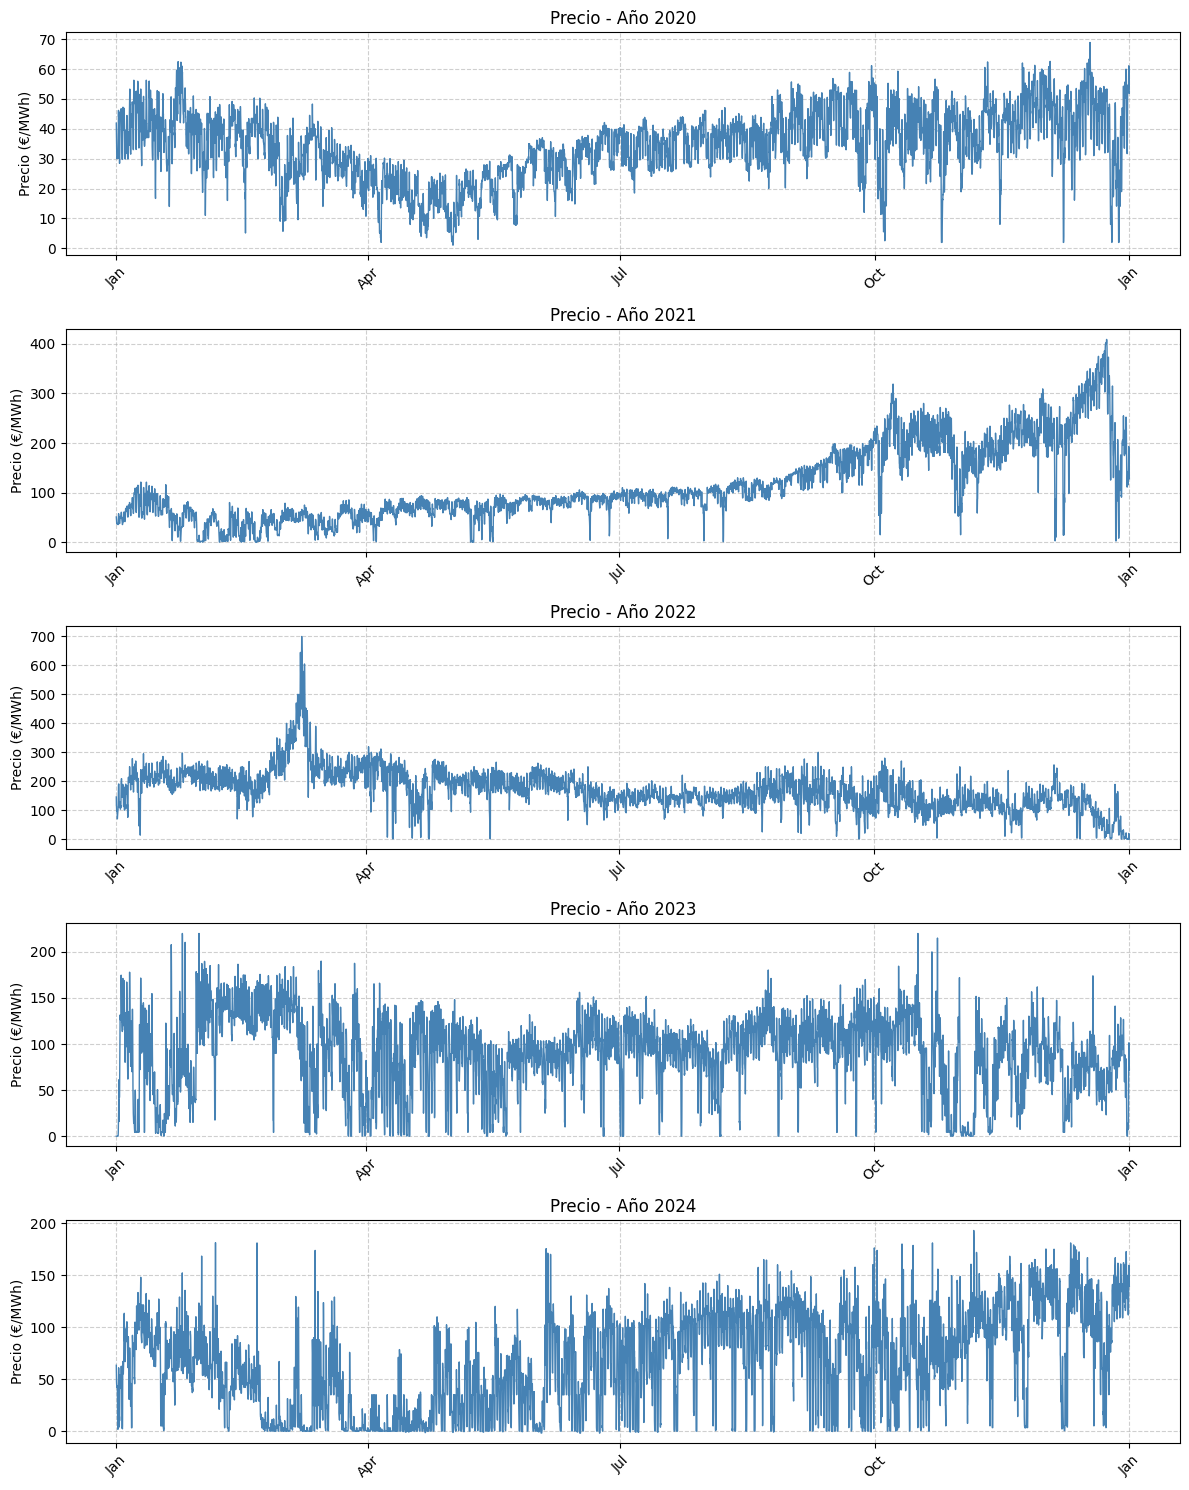

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ==============================
# 1. Cargar y preparar la serie (igual que antes)
# ==============================
df = pd.read_csv('limpiezaPrecio3_Omie2020_2024.csv', sep=";")
df['datetime'] = pd.to_datetime(df['datetime'])
#ordenar por fecha por si acaso
df.set_index('datetime', inplace=True)
df.sort_index(inplace=True) 

# ==============================
# 2. Grafica de precio por año (subplots)
# ==============================


# Extraer el año de cada fecha
df['year'] = df.index.year

# Obtener años únicos ordenados
years = sorted(df['year'].unique())

# Crear una figura con tantos subplots como años
fig, axes = plt.subplots(nrows=len(years), ncols=1, 
                         figsize=(12, 3*len(years)), 
                         sharex=False, sharey=False)

# Para cada año, graficar la serie de precios
for ax, year in zip(axes, years):
    data_year = df[df['year'] == year]
    ax.plot(data_year.index, data_year['price'], 
            color='steelblue', linewidth=1)
    ax.set_title(f'Precio - Año {year}', fontsize=12)
    ax.set_ylabel('Precio (€/MWh)')
    ax.grid(True, linestyle='--', alpha=0.6)
    # Formato del eje X para mostrar meses
    from matplotlib.dates import MonthLocator, DateFormatter
    ax.xaxis.set_major_locator(MonthLocator(bymonth=(1,4,7,10)))  # cada 3 meses
    ax.xaxis.set_major_formatter(DateFormatter('%b'))  # Ene, Feb...
    # Opcional: rotar etiquetas si se solapan
    ax.tick_params(axis='x', rotation=45)

# Ajustar espacio entre subplots y mostrar
plt.tight_layout()
plt.show()



